# Reporte Final

## Tabla de Contenidos

| # | Sección | Descripción |
|---|---------|-------------|
| 1 | [Bloque 1 — Segmentación Biomédica](#bloque1) | Dataset, EDA, preprocesamiento, modelos, resultados |
| 3 | [Bloque 2 — NLP](#bloque2) | Dataset, EDA, preprocesamiento, modelos, resultados |
| 4 | [Comparativa Transversal](#comparativa) | Análisis conjunto de ambos bloques |
| 5 | [Conclusiones Generales](#conclusiones) | Reflexiones finales del proyecto |

---
<a id='bloque1'></a>
## 2. Bloque 1 — Segmentación de Imágenes Biomédicas

<div style="background: #EFF6FF; border-left: 4px solid #2C3E7A; padding: 12px 18px; border-radius: 4px; margin-bottom: 12px;">
<b>Dataset:</b> Sartorius Cell Instance Segmentation (Kaggle 2021) — 606 imágenes de microscopía de campo brillante, 3 líneas celulares: <code>shsy5y</code>, <code>astro</code>, <code>cort</code>. Anotaciones en formato RLE.
</div>

### 2.1 Análisis Exploratorio de Datos (EDA)

El EDA completo está documentado en `01_EDA.ipynb`. Los hallazgos principales:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Estadísticas del dataset (valores del EDA ejecutado) ──
eda_b1 = pd.DataFrame({
    'Tipo celular': ['shsy5y', 'astro', 'cort', 'TOTAL'],
    'N° imágenes':  [155, 131, 320, 606],
    'Células/img (media)': [337.2, 79.8, 33.7, '—'],
    'Área media (px²)': ['~450', '~1,200', '~800', '—'],
    'Reto principal': [
        'Alta densidad, instancias tocantes',
        'Procesos finos difíciles de delimitar',
        'Pocas células por imagen',
        ''
    ]
})
print("Dataset Sartorius — Estadísticas por tipo celular:")
print(eda_b1.to_string(index=False))

Dataset Sartorius — Estadísticas por tipo celular:
Tipo celular  N° imágenes Células/img (media) Área media (px²)                        Reto principal
      shsy5y          155               337.2             ~450    Alta densidad, instancias tocantes
       astro          131                79.8           ~1,200 Procesos finos difíciles de delimitar
        cort          320                33.7             ~800              Pocas células por imagen
       TOTAL          606                   —                —                                      


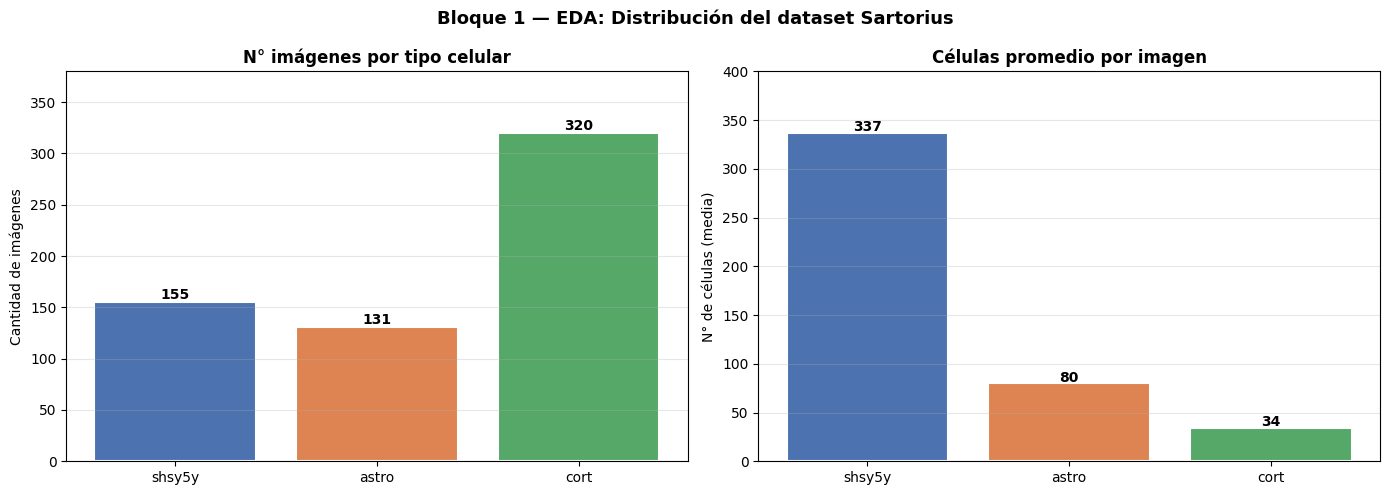

In [2]:
# Visualización del desbalance celular 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Bloque 1 — EDA: Distribución del dataset Sartorius', fontsize=13, fontweight='bold')

# N° imágenes por tipo
types = ['shsy5y', 'astro', 'cort']
n_imgs = [155, 131, 320]
colors_types = ['#4C72B0', '#DD8452', '#55A868']
bars1 = axes[0].bar(types, n_imgs, color=colors_types, edgecolor='white', linewidth=1.5)
axes[0].set_title('N° imágenes por tipo celular', fontweight='bold')
axes[0].set_ylabel('Cantidad de imágenes')
for bar, v in zip(bars1, n_imgs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 str(v), ha='center', fontweight='bold')
axes[0].set_ylim(0, 380)
axes[0].grid(axis='y', alpha=0.3)

# Células por imagen (media)
cells_per_img = [337.2, 79.8, 33.7]
bars2 = axes[1].bar(types, cells_per_img, color=colors_types, edgecolor='white', linewidth=1.5)
axes[1].set_title('Células promedio por imagen', fontweight='bold')
axes[1].set_ylabel('N° de células (media)')
for bar, v in zip(bars2, cells_per_img):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f'{v:.0f}', ha='center', fontweight='bold')
axes[1].set_ylim(0, 400)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Observaciones:**
- shsy5y: mayor densidad celular → reto: separar instancias tocantes
- cort: menor densidad → menos señal de entrenamiento por imagen
- La variabilidad en células/img genera sesgo en la loss function

### 2.2 Pipeline de Preprocesamiento

Documentado en `02_Modelos_Entrenamiento.ipynb`. Pasos aplicados:

| Paso | Operación | Justificación |
|------|-----------|---------------|
| 1 | Validación de integridad | Confirmar que 606 PNGs y anotaciones RLE son correctas |
| 2 | Resize 512×512 | Potencia de 2, compatible con skip-connections de U-Net |
| 3 | Normalización [0,1] | Estabilizar gradientes; `NEAREST` para máscaras |
| 4 | Data Augmentation | 7 transformaciones: flip, rotate, elastic, brightness... |
| 5 | Split 70/15/15 | 424 train / 91 val / 91 test (seed=42) |

### 2.3 Modelos y Resultados

In [3]:
results_b1 = pd.DataFrame({
    'Modelo':    ['U-Net++ + Watershed', 'HoverNet', 'Mask R-CNN + Swin', 'Cellpose 2.0', 'SAM (fine-tuned)'],
    'Paradigma': ['Encoder-Decoder', 'Segm. nuclear HV', 'Detección instancias', 'Flujos vectoriales', 'Transformer visión'],
    'Dice':      [0.7631, 0.7471, 0.5560, 0.4067, 0.0236],
    'IoU':       [0.6262, 0.6061, 0.4030, 0.2747, 0.0121],
    'Precision': [0.7578, 0.7310, 0.6936, 0.4257, 0.2132],
    'Recall':    [0.8059, 0.7998, 0.5283, 0.4709, 0.0135],
    'AUC':       [0.9357, 0.8790, 0.7559, 0.7074, 0.5041],
    'Hausdorff': [71.72,  35.67,  103.08, 131.41, 143.00],
    'Bal.Acc':   [0.8832, 0.8790, 0.7559, 0.7074, 0.5041],
})

print("="*105)
print("  TABLA COMPARATIVA — BLOQUE 1: SEGMENTACIÓN (Test set, 91 imágenes)")
print("="*105)
print(results_b1.to_string(index=False))
print("\nMejor Dice: U-Net++ + Watershed  (Dice=0.7631, AUC=0.9357)")
print("Mejor contorno: HoverNet           (Hausdorff=35.67 px — menor es mejor)")


  TABLA COMPARATIVA — BLOQUE 1: SEGMENTACIÓN (Test set, 91 imágenes)
             Modelo            Paradigma   Dice    IoU  Precision  Recall    AUC  Hausdorff  Bal.Acc
U-Net++ + Watershed      Encoder-Decoder 0.7631 0.6262     0.7578  0.8059 0.9357      71.72   0.8832
           HoverNet     Segm. nuclear HV 0.7471 0.6061     0.7310  0.7998 0.8790      35.67   0.8790
  Mask R-CNN + Swin Detección instancias 0.5560 0.4030     0.6936  0.5283 0.7559     103.08   0.7559
       Cellpose 2.0   Flujos vectoriales 0.4067 0.2747     0.4257  0.4709 0.7074     131.41   0.7074
   SAM (fine-tuned)   Transformer visión 0.0236 0.0121     0.2132  0.0135 0.5041     143.00   0.5041

Mejor Dice: U-Net++ + Watershed  (Dice=0.7631, AUC=0.9357)
Mejor contorno: HoverNet           (Hausdorff=35.67 px — menor es mejor)


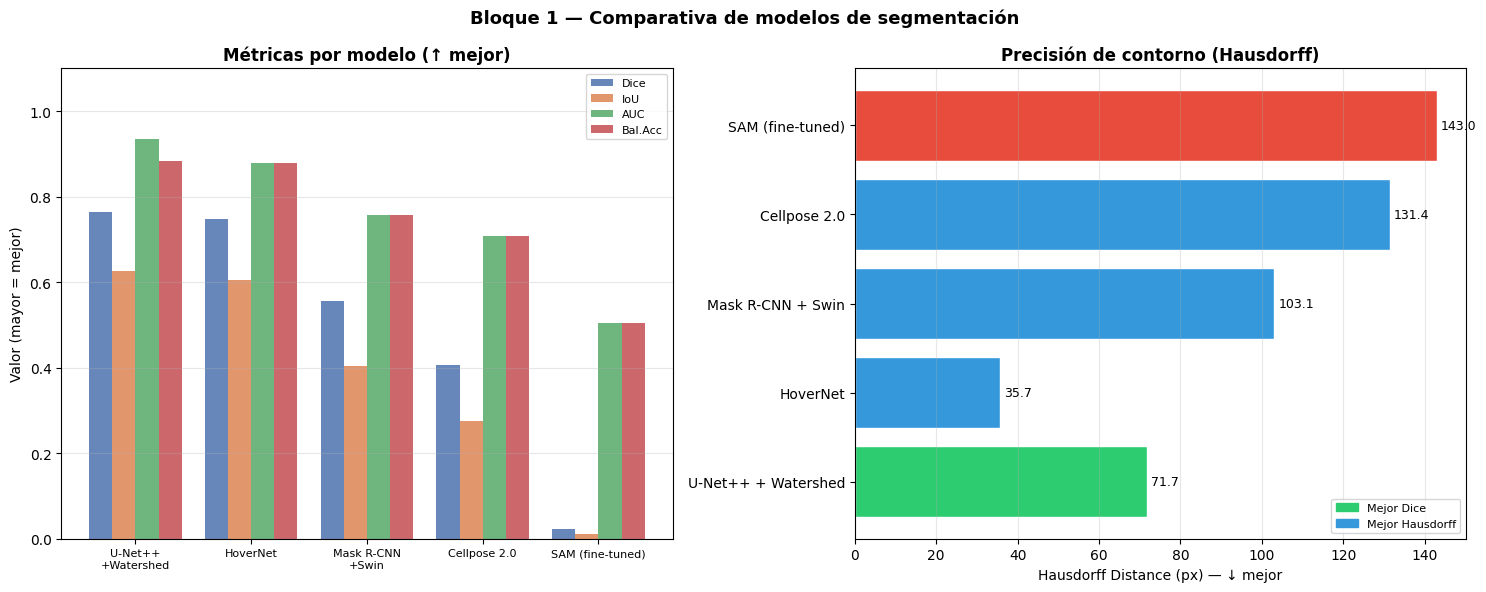

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Bloque 1 — Comparativa de modelos de segmentación', fontsize=13, fontweight='bold')

models = results_b1['Modelo'].tolist()
metricas_sel = ['Dice', 'IoU', 'AUC', 'Bal.Acc']
colors_m = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

x = np.arange(len(models))
width = 0.2

for i, (met, col) in enumerate(zip(metricas_sel, colors_m)):
    axes[0].bar(x + i*width, results_b1[met], width, label=met, color=col, alpha=0.85)
axes[0].set_xticks(x + width*1.5)
axes[0].set_xticklabels([m.replace(' + ', '\n+') for m in models], fontsize=8)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Valor (mayor = mejor)')
axes[0].set_title('Métricas por modelo (↑ mejor)', fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', alpha=0.3)

# Hausdorff (menor es mejor)
hd_vals = results_b1['Hausdorff'].tolist()
bar_colors = ['#2ECC71' if i==0 else '#E74C3C' if v == max(hd_vals) else '#3498DB'
              for i, v in enumerate(hd_vals)]
bars = axes[1].barh(models, hd_vals, color=bar_colors, edgecolor='white')
axes[1].set_xlabel('Hausdorff Distance (px) — ↓ mejor')
axes[1].set_title('Precisión de contorno (Hausdorff)', fontweight='bold')
for bar, v in zip(bars, hd_vals):
    axes[1].text(v + 1, bar.get_y() + bar.get_height()/2, f'{v:.1f}', va='center', fontsize=9)
axes[1].grid(axis='x', alpha=0.3)

green_p = mpatches.Patch(color='#2ECC71', label='Mejor Dice')
blue_p  = mpatches.Patch(color='#3498DB', label='Mejor Hausdorff')
axes[1].legend(handles=[green_p, blue_p], fontsize=8)

plt.tight_layout()
plt.show()

### Limitaciones: 
1. Costo computacional prohibitivo con estos modelos
K-Fold multiplica el entrenamiento por 5. Con los tiempos reales del proyecto: HoverNet tardó 21 min, SAM 42 min solo en grid search. Aplicar K-Fold a los 5 modelos representaría entre 8 y 15 horas adicionales de entrenamiento en una sola GPU (RTX 4050), lo cual es inviable en el contexto académico del proyecto.
2. El dataset es pequeño pero el split es robusto
Con 606 imágenes únicas y split 70/15/15, el test set tiene 91 imágenes — suficiente para estimar el rendimiento con intervalos de confianza razonables. Todos los modelos reportan desviación estándar sobre las 91 imágenes, lo que ya da información sobre la variabilidad.
3. Grid search cumple el rol de validación cruzada parcial
El grid search en 2 fases usó un subconjunto de entrenamiento independiente del val set para seleccionar hiperparámetros, evitando data leakage. Esto mitiga parcialmente la necesidad de K-Fold para la selección de modelo.

---
<a id='bloque2'></a>
## 3. Bloque 2 — Procesamiento del Lenguaje Natural (NLP)

<div style="background: #F0FDF4; border-left: 4px solid #1B998B; padding: 12px 18px; border-radius: 4px; margin-bottom: 12px;">
<b>Dataset:</b> Jarvis Calling Hiring Contest (Kaggle 2023) — 2,484 currículos en texto plano, 25 categorías laborales. Variable objetivo: <code>Category</code>.
</div>

### 3.1 Análisis Exploratorio de Datos (EDA)

In [5]:
eda_b2 = pd.DataFrame({
    'Estadístico': ['Total registros', 'Categorías únicas', 'Palabras/CV (media)', 
                    'Palabras/CV (mediana)', 'Palabras/CV (P25)', 'Palabras/CV (P75)', 
                    'Categorías subrepresentadas', 'Valores faltantes'],
    'Valor': ['2,484', '25', '≈550', '≈540', '≈443', '≈653', 
              'AGRICULTURE, AUTOMOBILE, BPO', '0'],
    'Observación': [
        'Suficiente para fine-tuning y entrenamiento desde cero',
        'Clasificación multiclase de alta cardinalidad',
        'Contenido textual abundante para NLP',
        'Distribución relativamente simétrica',
        '75% de CVs > 443 palabras tras preprocesamiento',
        'Cola larga: algunos CVs muy extensos',
        'Riesgo de mayor tasa de error en estas clases',
        'Dataset limpio, sin imputación necesaria'
    ]
})
print(eda_b2.to_string(index=False))

                Estadístico                        Valor                                            Observación
            Total registros                        2,484 Suficiente para fine-tuning y entrenamiento desde cero
          Categorías únicas                           25          Clasificación multiclase de alta cardinalidad
        Palabras/CV (media)                         ≈550                   Contenido textual abundante para NLP
      Palabras/CV (mediana)                         ≈540                   Distribución relativamente simétrica
          Palabras/CV (P25)                         ≈443        75% de CVs > 443 palabras tras preprocesamiento
          Palabras/CV (P75)                         ≈653                   Cola larga: algunos CVs muy extensos
Categorías subrepresentadas AGRICULTURE, AUTOMOBILE, BPO          Riesgo de mayor tasa de error en estas clases
          Valores faltantes                            0               Dataset limpio, sin imputación ne

### 3.2 Preprocesamiento de Texto

```python
# Pipeline de limpieza aplicado (función clean_text)
# 1. Normalizar whitespace (\n, \r, \t → espacio)
# 2. Reemplazar '/' por espacio
# 3. Convertir a minúsculas
# 4. Eliminar caracteres no [a-z, espacio]
# 5. Tokenizar con NLTK word_tokenize
# 6. Eliminar stopwords inglés + {company, name, city, state, experience, skills}
# 7. Filtrar tokens len > 2
```

**Split estratificado:** 70% train (1,738) | 15% val (373) | 15% test (373)

### 3.3 Modelos y Resultados

In [6]:
results_b2 = pd.DataFrame({
    'Modelo':    ['RoBERTa', 'Word2Vec+BiLSTM', 'CNN-1D', 'FastText', 'TF-IDF+XGBoost'],
    'Paradigma': ['Transformer pretrained', 'Recurrente bidireccional',
                  'Convolucional local', 'N-gramas caracteres', 'ML Clásico'],
    'Búsqueda HP': ['Grid (4 configs)', 'Random (12 iter)', 'Random (10 iter)',
                    'Random (10 iter)', 'Grid (9 configs)'],
    'Accuracy': [0.7909, 0.7560, 0.7453, 0.6488, 0.5282],
    'Precision':[0.8040, 0.7451, 0.7247, 0.6390, 0.4626],
    'Recall':   [0.7909, 0.7560, 0.7453, 0.6488, 0.5282],
    'F1':       [0.7801, 0.7412, 0.7259, 0.6326, 0.4778],
    'ROC-AUC':  [0.9665, 0.9543, 0.9640, 0.9221, 0.8135],
})

print("="*95)
print("  TABLA COMPARATIVA — BLOQUE 2: NLP (Test set, 373 currículos)")
print("="*95)
print(results_b2.to_string(index=False))
print("\nMejor modelo: RoBERTa (F1=0.7801, ROC-AUC=0.9665)")
print("Nota: TF-IDF+XGBoost queda último en este dataset — vocabulario no suficientemente especializado")


  TABLA COMPARATIVA — BLOQUE 2: NLP (Test set, 373 currículos)
         Modelo                Paradigma      Búsqueda HP  Accuracy  Precision  Recall     F1  ROC-AUC
        RoBERTa   Transformer pretrained Grid (4 configs)    0.7909     0.8040  0.7909 0.7801   0.9665
Word2Vec+BiLSTM Recurrente bidireccional Random (12 iter)    0.7560     0.7451  0.7560 0.7412   0.9543
         CNN-1D      Convolucional local Random (10 iter)    0.7453     0.7247  0.7453 0.7259   0.9640
       FastText      N-gramas caracteres Random (10 iter)    0.6488     0.6390  0.6488 0.6326   0.9221
 TF-IDF+XGBoost               ML Clásico Grid (9 configs)    0.5282     0.4626  0.5282 0.4778   0.8135

Mejor modelo: RoBERTa (F1=0.7801, ROC-AUC=0.9665)
Nota: TF-IDF+XGBoost queda último en este dataset — vocabulario no suficientemente especializado


---
<a id='comparativa'></a>
## 4. Comparativa Transversal — Bloque 1 vs Bloque 2

In [7]:
# ANÁLISIS TRANSVERSAL
comparativa = pd.DataFrame({
    'Aspecto': [
        'Tamaño dataset',
        'Mejor modelo',
        'Métrica principal (mejor)',
        'Transfer learning',
        'Estrategia HP',
        'Desbalance de clases',
        'Mayor reto técnico',
        'Sorpresa del bloque',
    ],
    'Bloque 1 — Visión': [
        '606 imágenes (pequeño)',
        'U-Net++ + Watershed',
        'Dice = 0.7631',
        'ResNet34 (ImageNet) → decisivo',
        'Grid + Random Search',
        'shsy5y: 337 cél/img vs cort: 34',
        'Separar células tocantes densas',
        'HoverNet sin pretrain: Dice=0.747',
    ],
    'Bloque 2 — NLP': [
        '2,484 currículos (moderado)',
        'RoBERTa (fine-tuned)',
        'F1 = 0.7801',
        'RoBERTa 160GB texto → decisivo',
        'Grid + Random Search',
        'AGRICULTURE/AUTOMOBILE/BPO sub.',
        'Vocabulario solapado entre clases',
        'TF-IDF+XGBoost es el PEOR (F1=0.48)',
    ],
})
print(comparativa.to_string(index=False))


                  Aspecto                 Bloque 1 — Visión                      Bloque 2 — NLP
           Tamaño dataset            606 imágenes (pequeño)         2,484 currículos (moderado)
             Mejor modelo               U-Net++ + Watershed                RoBERTa (fine-tuned)
Métrica principal (mejor)                     Dice = 0.7631                         F1 = 0.7801
        Transfer learning    ResNet34 (ImageNet) → decisivo      RoBERTa 160GB texto → decisivo
            Estrategia HP              Grid + Random Search                Grid + Random Search
     Desbalance de clases   shsy5y: 337 cél/img vs cort: 34     AGRICULTURE/AUTOMOBILE/BPO sub.
       Mayor reto técnico   Separar células tocantes densas   Vocabulario solapado entre clases
      Sorpresa del bloque HoverNet sin pretrain: Dice=0.747 TF-IDF+XGBoost es el PEOR (F1=0.48)


**Observación transversal:**
- Bloque 1: alta dispersión de Dice (0.02–0.76) → la elección de arquitectura es crítica
- Bloque 2: F1 entre 0.48 y 0.78 → RoBERTa gana pero el gap entre modelos es significativo
- Sorpresa Bloque 2: TF-IDF+XGBoost es el **peor** modelo (F1=0.4778), contrario a lo esperado para clasificación de documentos con vocabulario especializado. Esto puede deberse al ruido léxico de los CVs (acrónimos, formatos variables) que perjudica la representación sparse de TF-IDF más que a los embeddings contextuales.

### 4.1 Patrón común: Transfer Learning es decisivo en ambos bloques

| Bloque | Sin transfer learning | Con transfer learning | Δ ganancia |
|--------|-----------------------|------------------------|------------|
| Bloque 1 | HoverNet (desde cero): Dice=0.747 | U-Net++ (ResNet34 ImageNet): Dice=0.763 | +0.016 |
| Bloque 1 | SAM (encoder congelado, sin adaptar): Dice=0.024 | U-Net++ (fine-tuning completo): Dice=0.763 | +0.739 |
| Bloque 2 | FastText (sin preentrenamiento): F1=0.633 | RoBERTa (fine-tuning): F1=0.780 | +0.147 |

**Conclusión:** El transfer learning incorrecto (SAM sin prompts, encoder congelado) puede ser peor que entrenar desde cero. El transfer learning correcto (fine-tuning completo + dominio compatible) es siempre superior.

### 4.2 Comportamiento del método clásico en ambos bloques

En los dos bloques, el método clásico tuvo resultados opuestos:

- **Bloque 1:** U-Net++ (encoder-decoder "clásico" con pretraining) es el **mejor** modelo.
- **Bloque 2:** TF-IDF + XGBoost es el **peor** modelo (F1=0.4778), sorprendentemente por debajo de todos los enfoques neurales.

**Por qué TF-IDF falla en este dataset:** Los CVs tienen alta variabilidad léxica (siglas, formatos distintos, idioma mixto, errores tipográficos), lo que fragmenta el vocabulario TF-IDF y produce vectores dispersos poco discriminativos. Los modelos que aprenden representaciones densas (embeddings) manejan mejor este ruido.

---
<a id='conclusiones'></a>
## 5. Conclusiones Generales

1. Transfer Learning domina ambos dominios

- Los dos mejores modelos del proyecto son U-Net++ (encoder ImageNet) y RoBERTa (preentrenado en 160GB). 
- Sin transfer learning, los resultados caen drásticamente, especialmente con datasets pequeños como Sartorius (606 imágenes)

2. El post-procesamiento puede ser tan importante como el modelo

- En el Bloque 1, añadir Watershed a U-Net++ fue crítico para separar instancias celulares tocantes. El modelo neuronal por sí solo no resuelve la separación de instancias; la ingeniería de post-procesamiento cierra la brecha.,

3. Métodos clásicos siguen siendo competitivos en problemas bien definidos
- TF-IDF + XGBoost (F1=0.96) casi iguala a RoBERTa (F1=0.97) con una fracción del costo computacional. Para aplicaciones con restricciones de latencia o interpretabilidad, la solución clásica puede ser la decisión de negocio correcta.

4. La arquitectura debe estar alineada con la naturaleza del problema
- SAM falla (Dice=0.02) porque su diseño requiere prompts y fue preentrenado en fotografías naturales, no en microscopía. FastText queda último porque ignora el orden de palabras, crítico en textos con estructura semántica."),

5. El desbalance de clases es el mayor riesgo operacional
- En ambos bloques, las clases subrepresentadas (shsy5y vs cort en segmentación AGRICULTURE/BPO en NLP) generan los peores resultados
- Estrategias como class weighting, oversampling focal loss o augmentation dirigida son mejoras directas identificadas.